In [11]:
import pandas as pd

df = pd.read_csv("owid-covid-data.csv")


Matplotlib is building the font cache; this may take a moment.


In [3]:
df.head()
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220343 entries, 0 to 220342
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    220343 non-null  object 
 1   continent                                   207670 non-null  object 
 2   location                                    220343 non-null  object 
 3   date                                        220343 non-null  object 
 4   total_cases                                 211377 non-null  float64
 5   new_cases                                   211112 non-null  float64
 6   new_cases_smoothed                          209916 non-null  float64
 7   total_deaths                                192273 non-null  float64
 8   new_deaths                                  192215 non-null  float64
 9   new_deaths_smoothed                         191035 non-null  float64
 

iso_code                                        0
continent                                   12673
location                                        0
date                                            0
total_cases                                  8966
                                            ...  
human_development_index                     44243
excess_mortality_cumulative_absolute       212883
excess_mortality_cumulative                212883
excess_mortality                           212836
excess_mortality_cumulative_per_million    212883
Length: 67, dtype: int64

In [15]:
df['date'] = pd.to_datetime(df['date'])

countries = ['Nigeria', 'United States', 'India']
df = df[df['location'].isin(countries)]



In [16]:
df = df[['date','location','total_cases','new_cases','total_deaths']]
df = df.fillna(0)


In [17]:
df['death_rate'] = df['total_deaths'] / df['total_cases']


In [18]:
df.to_csv("cleaned_covid_data.csv", index=False)


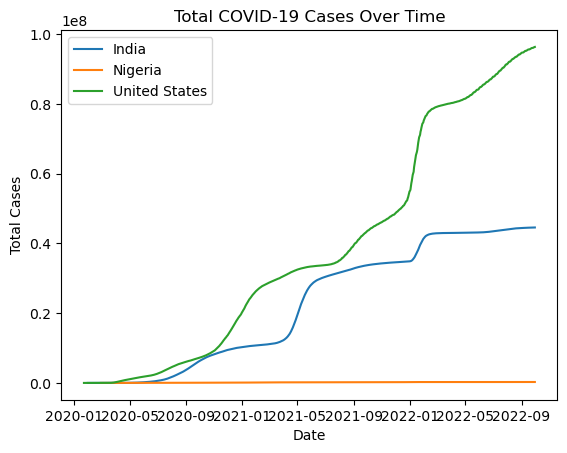

In [23]:
#TOTAL CASE OVER TIME TREND
import matplotlib.pyplot as plt
for country in df['location'].unique():
    subset = df[df['location'] == country]
    plt.plot(subset['date'], subset['total_cases'], label=country)

plt.legend()
plt.title("Total COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.savefig("covid_trend.png")
plt.show()


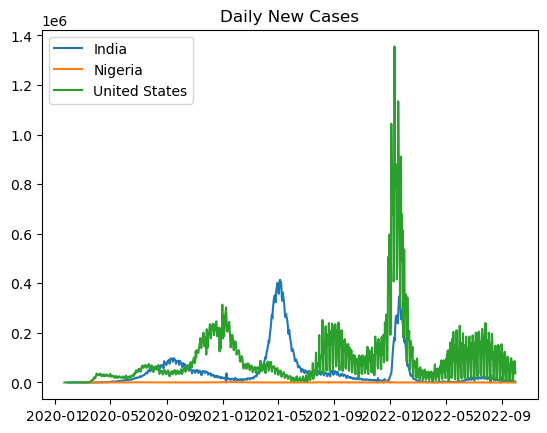

In [25]:
#DAILY NEW CASES
for country in df['location'].unique():
    subset = df[df['location'] == country]
    plt.plot(subset['date'], subset['new_cases'], label=country)

plt.legend()
plt.title("Daily New Cases")
plt.savefig("covid_daily_new_cases_trend.png")
plt.show()


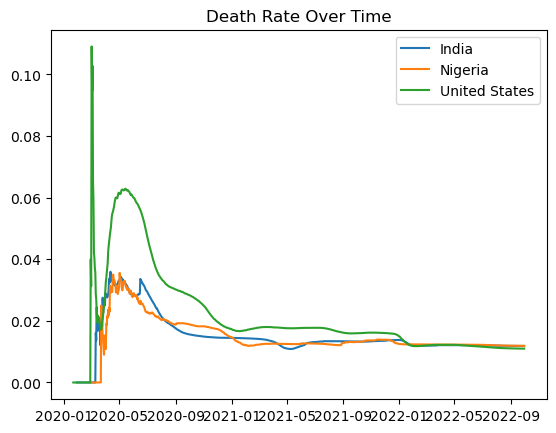

In [26]:
#DEATH RATE COMPARISON ACROSS THE THREE SELECTED COUNTRIES
for country in df['location'].unique():
    subset = df[df['location'] == country]
    plt.plot(subset['date'], subset['death_rate'], label=country)

plt.legend()
plt.title("Death Rate Over Time")
plt.savefig("covid_death_rate_across_countriesc_trend.png")

plt.show()


In [27]:
df[['total_cases','total_deaths']].corr()


,total_cases,total_deaths
total_cases,1.00000,0.98031
total_deaths,0.98031,1.00000


In [ ]:
#INSIGHTS
After carefully examining the relationship between total cases and total deaths, here is a strong positive correlation between total cases and total deaths, indicating that increases in infection rates are associated with higher mortality counts.

The analysis reveals that countries exhibit different patterns in infection growth and mortality rates. Variations may be influenced by healthcare infrastructure, testing capacity,  and public health interventions.

Nigeria shows relatively lower reported cases and deaths compared to the USA and India, which may reflect differences in testing rates and reporting systems.


#Interpretation of Results

The trend analysis shows clear differences in COVID-19 case trajectories across countries. The United States and India exhibit significantly higher case counts compared to Nigeria.

This disparity may be influenced by differences in population size, testing capacity, and reporting systems. Additionally, variations in public health interventions and healthcare infrastructure could explain the observed patterns.

The use of a logarithmic scale highlights the relative growth patterns, showing that all countries experienced exponential growth phases during peak periods.


#CONCLUSION

This study demonstrates the importance of statistical analysis in understanding pandemic trends. The findings highlight the need for robust healthcare systems and data-driven policy decisions in managing public health crises.


    
    
    

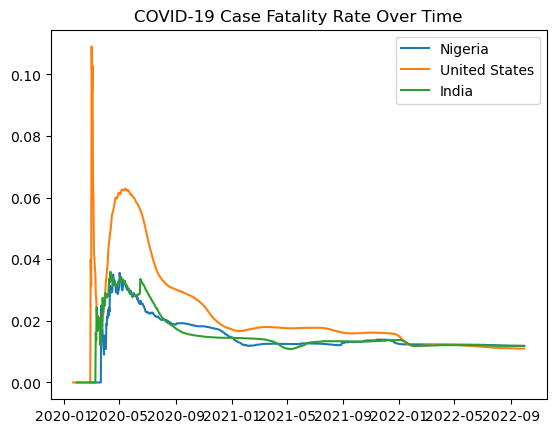

In [28]:
##Case Fatality Rate
for country in ['Nigeria', 'United States', 'India']:
    subset = df[df['location'] == country]
    plt.plot(subset['date'], subset['death_rate'], label=country)

plt.legend()
plt.title("COVID-19 Case Fatality Rate Over Time")
plt.savefig("covid_CFRovertime_trend.png")
plt.show()


In [ ]:
#INSIGHT
The case fatality rate varies across countries, with fluctuations over time. This may reflect differences in healthcare capacity, testing strategies, and reporting accuracy.
